<a href="https://colab.research.google.com/github/Aswin123358/IPL-Match-Winner-Prediction-Model/blob/main/IPL_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import zipfile

zip_path = '/content/archive.zip'   # your file name
extract_path = '/content/data'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Unzipped successfully!")

Unzipped successfully!


In [2]:
import os
os.listdir('/content/data')

['teams_data.csv',
 'ipl_matches_data.csv',
 'team_aliases.csv',
 'players-data-updated.csv',
 'ball_by_ball_data.csv']

In [ ]:
!pip install pandas numpy scikit-learn matplotlib seaborn

In [4]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

print("All libraries working ✅")

All libraries working ✅


In [5]:
df = pd.read_csv('/content/data/ipl_matches_data.csv')
df.head()

,match_id,season_id,balls_per_over,city,match_date,event_name,match_number,gender,match_type,format,...,venue,toss_winner,team1,team2,toss_decision,match_winner,win_by_runs,win_by_wickets,player_of_match,result
0,335982,2008,6,Bangalore,2008-04-18,Indian Premier League,1.0,male,T20,T20,...,M Chinnaswamy Stadium,1,1,6,field,6,140.0,NaN,46.0,win
1,1082591,2017,6,Hyderabad,2017-04-05,Indian Premier League,1.0,male,T20,T20,...,"Rajiv Gandhi International Stadium, Uppal",1,2,1,field,2,35.0,NaN,15.0,win
2,1082592,2017,6,Pune,2017-04-06,Indian Premier League,2.0,male,T20,T20,...,Maharashtra Cricket Association Stadium,4,4,3,field,4,NaN,7.0,36.0,win
3,1082593,2017,6,Rajkot,2017-04-07,Indian Premier League,3.0,male,T20,T20,...,Saurashtra Cricket Association Stadium,6,5,6,field,6,NaN,10.0,57.0,win
4,1082594,2017,6,Indore,2017-04-08,Indian Premier League,4.0,male,T20,T20,...,Holkar Cricket Stadium,494,494,4,field,494,NaN,6.0,71.0,win


In [6]:
df.columns

Index(['match_id', 'season_id', 'balls_per_over', 'city', 'match_date',
       'event_name', 'match_number', 'gender', 'match_type', 'format', 'overs',
       'season', 'team_type', 'venue', 'toss_winner', 'team1', 'team2',
       'toss_decision', 'match_winner', 'win_by_runs', 'win_by_wickets',
       'player_of_match', 'result'],
      dtype='object')

In [7]:
df = df[['team1','team2','toss_winner','toss_decision','venue','match_winner']]
df = df.dropna()
df.head()

,team1,team2,toss_winner,toss_decision,venue,match_winner
0,1,6,1,field,M Chinnaswamy Stadium,6
1,2,1,1,field,"Rajiv Gandhi International Stadium, Uppal",2
2,4,3,4,field,Maharashtra Cricket Association Stadium,4
3,5,6,6,field,Saurashtra Cricket Association Stadium,6
4,494,4,494,field,Holkar Cricket Stadium,494


In [8]:
X = df.drop('match_winner', axis=1)
y = df['match_winner']

In [9]:
df.columns = df.columns.str.strip().str.lower()
df.columns

Index(['team1', 'team2', 'toss_winner', 'toss_decision', 'venue',
       'match_winner'],
      dtype='object')

In [10]:
# Create win flag
df['team1_win'] = (df['match_winner'] == df['team1']).astype(int)

# Combine both teams into one column
teams = pd.concat([df[['team1', 'team1_win']].rename(columns={'team1':'team'}),
                   df[['team2', 'team1_win']].rename(columns={'team2':'team'})])

# Calculate overall team strength
team_strength = teams.groupby('team')['team1_win'].mean().to_dict()

# Map strength
df['team1_strength'] = df['team1'].map(team_strength)
df['team2_strength'] = df['team2'].map(team_strength)

df = df.drop('team1_win', axis=1)

In [11]:
df['toss_win_match'] = (df['toss_winner'] == df['match_winner']).astype(int)

In [12]:
df = pd.get_dummies(df)

In [13]:
original_winners = df['match_winner'].copy()

In [14]:
!pip install xgboost

In [15]:
# Encode target
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['match_winner'] = le.fit_transform(df['match_winner'])

# Split
X = df.drop('match_winner', axis=1)
y = df['match_winner']

In [16]:
from xgboost import XGBClassifier

X = df.drop('match_winner', axis=1)
y = df['match_winner']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = XGBClassifier(
    n_estimators=400,
    learning_rate=0.03,
    max_depth=10
)

model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.03, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=10,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=400,
              n_jobs=None, num_parallel_tree=None, ...)

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X = df.drop('match_winner', axis=1)
y = df['match_winner']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=200, max_depth=15)
model.fit(X_train, y_train)

RandomForestClassifier(max_depth=15, n_estimators=200)

In [18]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7649572649572649


In [19]:
def predict_winner(sample):
    pred = model.predict(sample)
    team_name = le.inverse_transform(pred)
    return team_name[0]

In [20]:
sample = X_test.iloc[0:1]
print("Predicted Winner:", predict_winner(sample))

Predicted Winner: 129


In [21]:
probs = model.predict_proba(sample)
print("Win Probability:", probs)

Win Probability: [[0.00849678 0.02773574 0.02457308 0.00286255 0.01223353 0.03780109
  0.50625256 0.05725646 0.11804437 0.17965141 0.00210404 0.01021785
  0.00623989 0.00653063]]


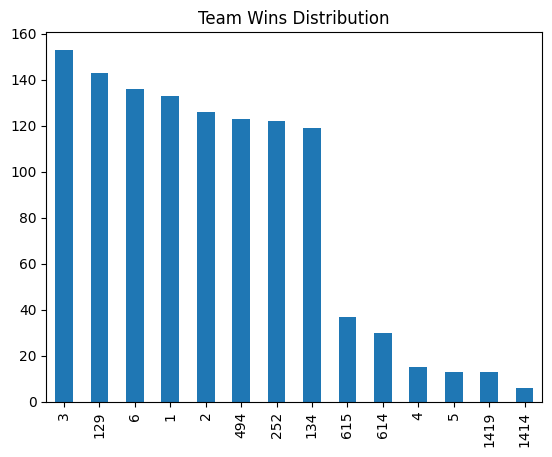

In [22]:
import matplotlib.pyplot as plt

pd.Series(le.inverse_transform(y)).value_counts().plot(kind='bar')
plt.title("Team Wins Distribution")
plt.show()

In [23]:
pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 64.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 102.4 MB/s eta 0:00:00


In [24]:
import pickle

# Save model
pickle.dump(model, open('ipl_model.pkl', 'wb'))

# Save encoder
pickle.dump(le, open('label_encoder.pkl', 'wb'))

print("Saved successfully!")

Saved successfully!


In [25]:
%%writefile app.py
import streamlit as st
import pandas as pd
import pickle

# ✅ Team mapping (ID ↔ Name)
team_map = {
    1: "Chennai Super Kings",
    2: "Mumbai Indians",
    3: "Royal Challengers Bangalore",
    4: "Kolkata Knight Riders",
    5: "Delhi Capitals",
    6: "Punjab Kings",
    129: "Rajasthan Royals",
    134: "Sunrisers Hyderabad",
    252: "Lucknow Super Giants",
    494: "Gujarat Titans"
}

reverse_map = {v: k for k, v in team_map.items()}
teams = list(team_map.values())

# ✅ Load model & encoder
model = pickle.load(open('ipl_model.pkl', 'rb'))
le = pickle.load(open('label_encoder.pkl', 'rb'))

st.title("🏏 IPL Match Winner Prediction")

# ✅ User Inputs
team1 = st.selectbox("Team 1", teams)
team2 = st.selectbox("Team 2", teams)

toss_winner = st.selectbox("Toss Winner", [team1, team2])
toss_decision = st.selectbox("Toss Decision", ["bat", "field"])

# ✅ Prediction
if st.button("Predict Winner"):

    # Convert names → IDs
    team1_id = reverse_map[team1]
    team2_id = reverse_map[team2]
    toss_winner_id = reverse_map[toss_winner]

    # Create input (MATCH TRAINING FORMAT)
    input_dict = {
        'team1_' + str(team1_id): 1,
        'team2_' + str(team2_id): 1,
        'toss_winner_' + str(toss_winner_id): 1,
        'toss_decision_bat': 1 if toss_decision == "bat" else 0,
        'toss_decision_field': 1 if toss_decision == "field" else 0
    }

    input_df = pd.DataFrame([input_dict]).fillna(0)

    # Match model columns
    model_cols = model.feature_names_in_
    input_df = input_df.reindex(columns=model_cols, fill_value=0)

   # Get probabilities
    probs = model.predict_proba(input_df)[0]
    class_ids = list(le.classes_)

    # Get index of selected teams
    team1_index = class_ids.index(team1_id) if team1_id in class_ids else -1
    team2_index = class_ids.index(team2_id) if team2_id in class_ids else -1

    team1_prob = probs[team1_index] if team1_index != -1 else 0
    team2_prob = probs[team2_index] if team2_index != -1 else 0

    # Decide winner ONLY between selected teams
    if team1_prob > team2_prob:
        winner_name = team1
    else:
        winner_name = team2

    st.success(f"🏆 Predicted Winner: {winner_name}")

    # ✅ Probability calculation (FIXED)
    probs = model.predict_proba(input_df)[0]
    class_ids = list(le.classes_)

    # Get correct index of both teams
    team1_index = class_ids.index(team1_id) if team1_id in class_ids else -1
    team2_index = class_ids.index(team2_id) if team2_id in class_ids else -1

    team1_prob = probs[team1_index] if team1_index != -1 else 0
    team2_prob = probs[team2_index] if team2_index != -1 else 0

    # Normalize
    total = team1_prob + team2_prob
    team1_prob = (team1_prob / total) * 100 if total != 0 else 0
    team2_prob = (team2_prob / total) * 100 if total != 0 else 0

    # Show result
    st.subheader("Win Probability")
    st.write(f"{team1} : {round(team1_prob,2)}%")
    st.write(f"{team2} : {round(team2_prob,2)}%")

Writing app.py


In [26]:
!pip install pyngrok

In [27]:
!ngrok config add-authtoken 3CGCd1GokA0g6tMYNl9VFGozl8r_59ohJ2UtCseb3x7YyR14X

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [29]:
from pyngrok import ngrok
import os

public_url = ngrok.connect(8080)
print(public_url)

os.system("streamlit run app.py &")

NgrokTunnel: "https://glucose-whoopee-slashed.ngrok-free.dev" -> "http://localhost:8080"


0